# Figure 2. Sex-associated variation in cardiac cellular abundance, gene expression and hormonal signalling

3 panels of this figure are built below, one section each.

---

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']
import sys
sys.path[:0] = ["../src", "../figures/_lib", "../figures/Fig2"]
from hhca.paths import TABLES, OUT
print('inputs :', TABLES)
print('outputs:', OUT)

inputs : /Volumes/Storage/hhca_spatial_tables
outputs: /Users/maiia.shulman/hhca_release_out


## Fig2 j, k, l

Fig2 j, k, l: per-donor gene-set scores by sex on the 280 canonical donors (port of heart_results/fig2_sexage_280/render_def.py).

Input:
- `heart_results/age_differences/tables/per_donor_celltype_scores_CANON280.npz`

Source: `figures/Fig2/panel_jkl.py`

donors 280 | j: nF=36 nM=78 p=1.329e-03 g=+0.787 | l: nF=80 nM=154 p=8.446e-05 g=+0.496


None


None


None


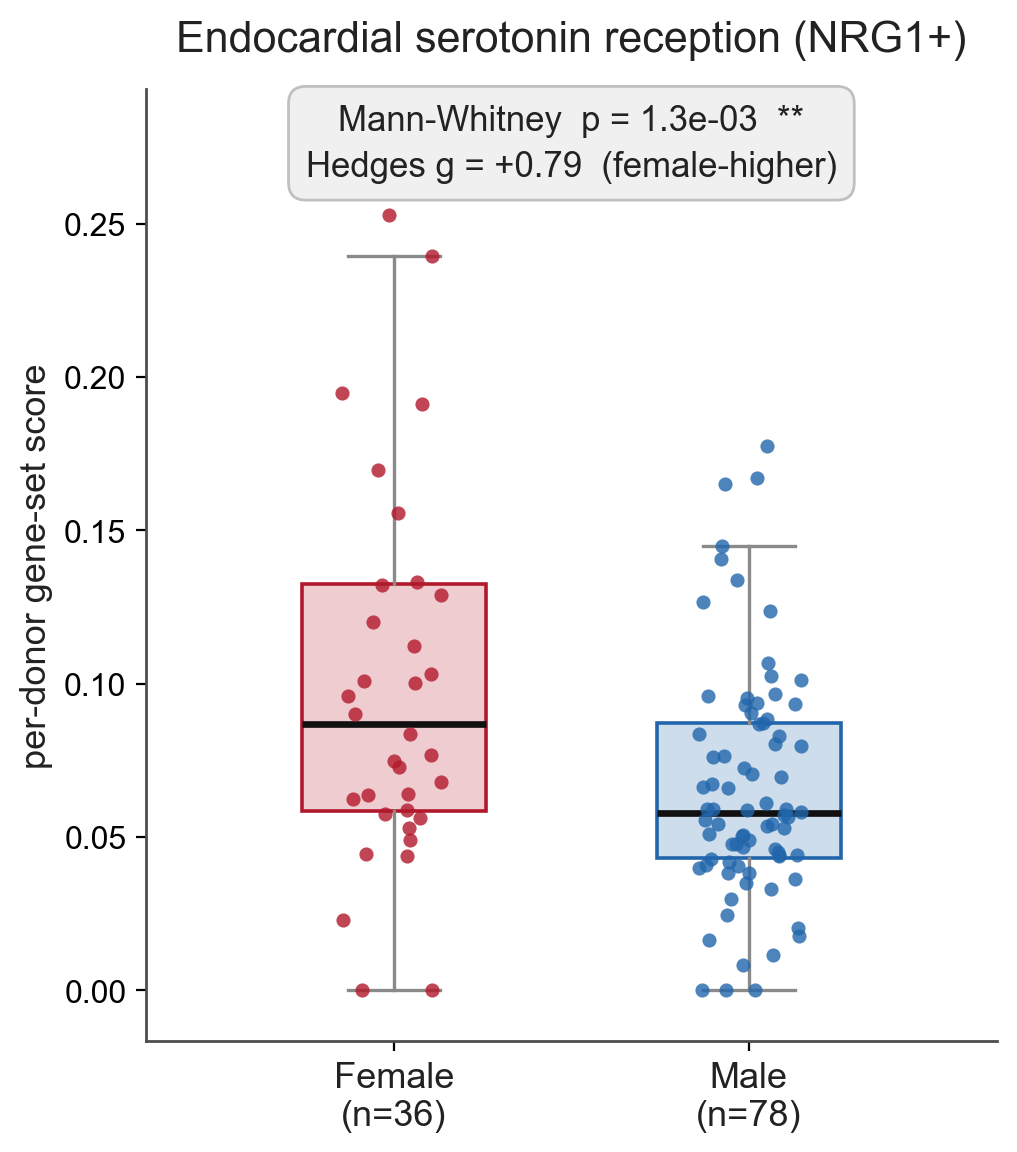

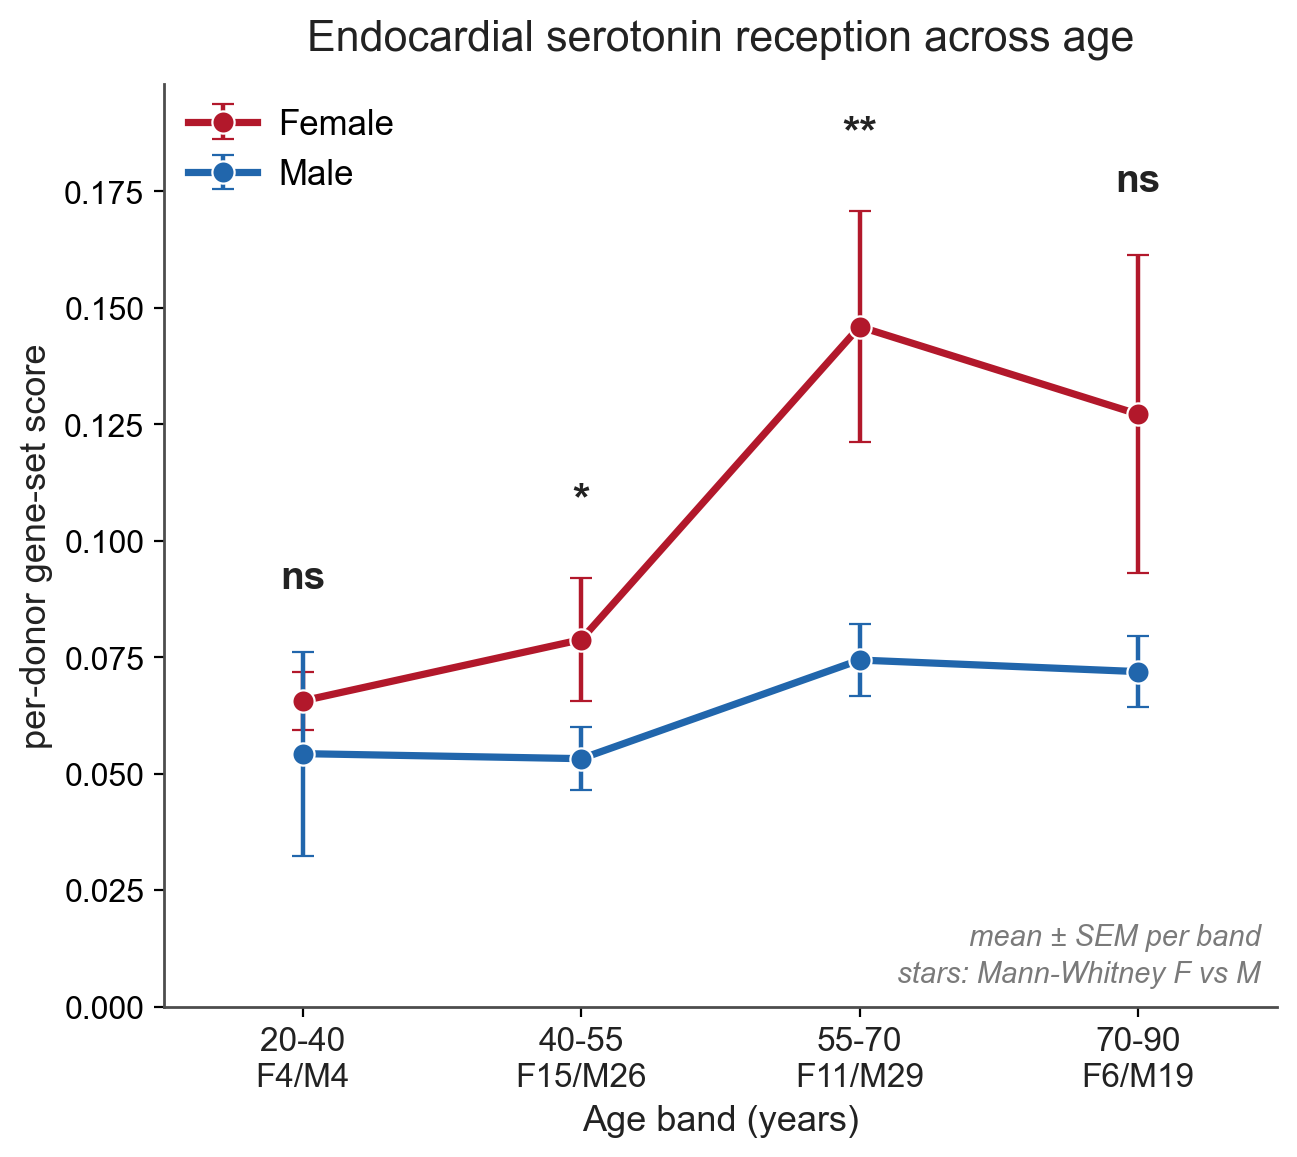

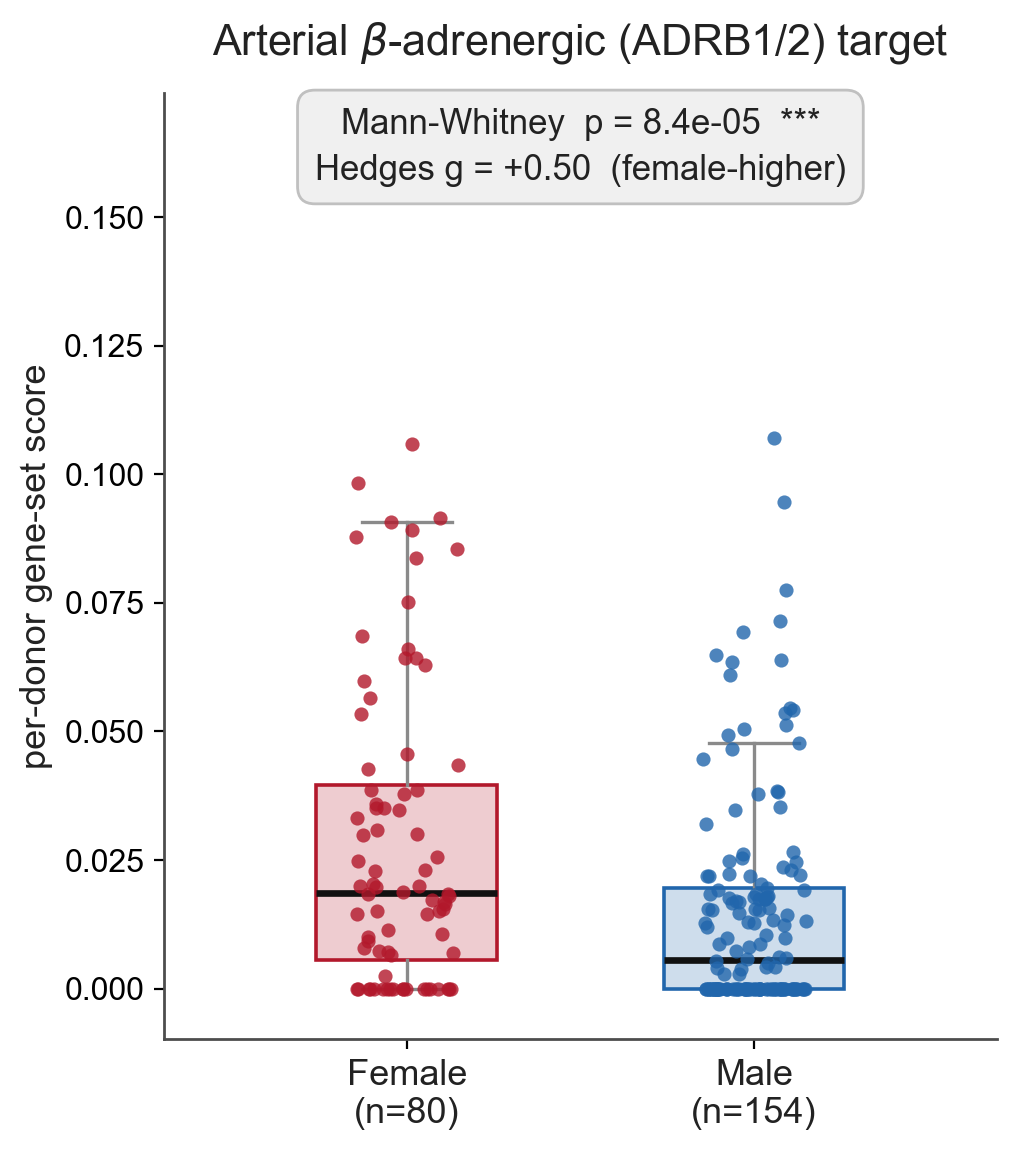

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

from hhca.paths import TABLES
from pubfig import save

NPZ = f"{TABLES}/heart_results/age_differences/tables/per_donor_celltype_scores_CANON280.npz"
matplotlib.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
})
SEX = {"female": "#B2182B", "male": "#2166AC"}
INK = "#222222"; MUTED = "#7A7A7A"; WHISK = "#8a8a8a"
SERO_G, SERO_L, SERO_CT = 2749, "L4", "Endocardial Endothelial Cells - NRG1+"
BADR_G, BADR_L, BADR_CT = 2446, "L3", "Arterial Endothelial cells"
BANDS = [(20, 40), (40, 55), (55, 70), (70, 90)]


def hedges_g_FM(F, M):
    nf, nm = len(F), len(M)
    sp = np.sqrt(((nm - 1) * np.var(M, ddof=1) + (nf - 1) * np.var(F, ddof=1)) / (nm + nf - 2))
    return (np.mean(F) - np.mean(M)) / sp * (1 - 3 / (4 * (nm + nf) - 9))


def stars(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"


class Scores:
    def __init__(self, npz):
        z = np.load(npz, allow_pickle=True)
        self.z = z
        self.sex = np.array([str(s) for s in z["donor_sex"]])
        self.age = np.asarray(z["donor_age"], float)
        self.nD = len(self.sex)

    def perdonor(self, level, ct, gidx, min_cells=10):
        z = self.z
        cats = list(z[f"cats__{level}"]); nct = len(cats); c = cats.index(ct)
        sums = z[f"sums__{level}"]; cnts = z[f"cnts__{level}"]
        sc = np.full(self.nD, np.nan)
        for d in range(self.nD):
            row = d * nct + c; n = cnts[row]
            if n >= min_cells:
                sc[d] = sums[row, gidx] / n
        return sc

    def split(self, level, ct, gidx, min_cells=10):
        sc = self.perdonor(level, ct, gidx, min_cells)
        ok = ~np.isnan(sc) & (self.age >= 20) & (self.age <= 89)
        return sc[ok & (self.sex == "female")], sc[ok & (self.sex == "male")]

    def banded(self, level, ct, gidx, bands, min_cells=10):
        sc = self.perdonor(level, ct, gidx, min_cells)
        ok = ~np.isnan(sc) & (self.age >= 20) & (self.age <= 89)
        out = []
        for lo, hi in bands:
            m = ok & (self.age >= lo) & (self.age < hi)
            out.append((sc[m & (self.sex == "female")], sc[m & (self.sex == "male")]))
        return out


def _despine(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color("#4d4d4d"); ax.spines["bottom"].set_color("#4d4d4d")
    ax.spines["left"].set_linewidth(1.0); ax.spines["bottom"].set_linewidth(1.0)


def box_panel(ax, F, M, title, p, g, seed):
    rng = np.random.default_rng(seed)               # seeded jitter, as in the source render
    data = [F, M]; names = ["female", "male"]
    bp = ax.boxplot(data, positions=[0, 1], widths=0.52, patch_artist=True,
                    showfliers=False, whis=1.5, zorder=2)
    for i, name in enumerate(names):
        col = SEX[name]
        bp["boxes"][i].set(facecolor=matplotlib.colors.to_rgba(col, 0.22), edgecolor=col, linewidth=1.3)
        bp["medians"][i].set(color="#111111", linewidth=2.4)
        for w in (bp["whiskers"][2 * i], bp["whiskers"][2 * i + 1]):
            w.set(color=WHISK, linewidth=1.2)
        for cp in (bp["caps"][2 * i], bp["caps"][2 * i + 1]):
            cp.set(color=WHISK, linewidth=1.2)
    for i, (vals, name) in enumerate(zip(data, names)):
        jit = (rng.random(len(vals)) - 0.5) * 0.30
        ax.scatter(np.full(len(vals), i) + jit, vals, s=26, color=SEX[name], alpha=0.80,
                   linewidths=0.0, zorder=3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"Female\n(n={len(F)})", f"Male\n(n={len(M)})"], fontsize=13, color=INK)
    ax.set_xlim(-0.7, 1.7)
    ax.set_ylabel("per-donor gene-set score", fontsize=13, color=INK)
    ax.set_title(title, fontsize=15.5, color=INK, pad=14)
    ax.tick_params(axis="y", labelsize=11.5)
    ax.margins(y=0.06)
    _despine(ax)
    txt = (f"Mann-Whitney  p = {p:.1e}  {stars(p)}\n"
           f"Hedges g = {g:+.2f}  (female-higher)")
    ax.text(0.5, 0.985, txt, transform=ax.transAxes, ha="center", va="top", fontsize=12.5,
            color=INK, linespacing=1.5,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", edgecolor="#c0c0c0", linewidth=1.0))


def age_panel(ax, bands, band_scores, title):
    bandlabels = [f"{lo}-{hi}" for lo, hi in bands]
    x = np.arange(len(bands))
    series = {}
    for name in ("female", "male"):
        means, sems = [], []
        for (F, M) in band_scores:
            v = F if name == "female" else M
            means.append(np.mean(v)); sems.append(np.std(v, ddof=1) / np.sqrt(len(v)))
        series[name] = (np.array(means), np.array(sems))
    for name in ("female", "male"):
        mu, se = series[name]
        ax.errorbar(x, mu, yerr=se, color=SEX[name], lw=2.6, marker="o", ms=8, mfc=SEX[name],
                    mec="white", mew=0.8, capsize=4, capthick=1.6, elinewidth=1.6, zorder=3,
                    label=name.capitalize())
    fmu, fse = series["female"]; mmu, mse = series["male"]
    ymax = float(np.nanmax([(fmu + fse).max(), (mmu + mse).max()]))
    for i, (F, M) in enumerate(band_scores):
        p = mannwhitneyu(F, M).pvalue if (len(F) >= 3 and len(M) >= 3) else np.nan
        s = stars(p) if p == p else "ns"
        ytop = max(fmu[i] + fse[i], mmu[i] + mse[i]) + 0.012
        ax.text(i, ytop, s, ha="center", va="bottom", fontsize=16 if s != "ns" else 14,
                weight="bold", color=INK)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{bl}\nF{len(F)}/M{len(M)}" for bl, (F, M) in zip(bandlabels, band_scores)],
                       fontsize=12, color=INK)
    ax.set_xlim(-0.5, len(bands) - 0.5)
    ax.set_ylim(0, ymax * 1.16)
    ax.set_xlabel("Age band (years)", fontsize=13, color=INK)
    ax.set_ylabel("per-donor gene-set score", fontsize=13, color=INK)
    ax.set_title(title, fontsize=15.5, color=INK, pad=12)
    ax.tick_params(axis="y", labelsize=11.5)
    _despine(ax)
    ax.legend(loc="upper left", fontsize=12.5, frameon=False, handletextpad=0.6, borderpad=0.2,
              labelspacing=0.5)
    ax.text(0.985, 0.02, "mean ± SEM per band\nstars: Mann-Whitney F vs M",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=10.5, color=MUTED,
            style="italic", linespacing=1.4)


S = Scores(NPZ)
dF, dM = S.split(SERO_L, SERO_CT, SERO_G)
fF, fM = S.split(BADR_L, BADR_CT, BADR_G)
eb = S.banded(SERO_L, SERO_CT, SERO_G, BANDS)
dp, dg = mannwhitneyu(dF, dM).pvalue, hedges_g_FM(dF, dM)
fp, fg = mannwhitneyu(fF, fM).pvalue, hedges_g_FM(fF, fM)
print(f"donors {S.nD} | j: nF={len(dF)} nM={len(dM)} p={dp:.3e} g={dg:+.3f} | "
      f"l: nF={len(fF)} nM={len(fM)} p={fp:.3e} g={fg:+.3f}")

fig, ax = plt.subplots(figsize=(5.2, 5.9))
box_panel(ax, dF, dM, "Endocardial serotonin reception (NRG1+)", dp, dg, seed=23)
fig.tight_layout()
print(save(fig, "Fig2", "j", bbox_inches="tight"))

fig, ax = plt.subplots(figsize=(6.6, 5.9))
age_panel(ax, BANDS, eb, "Endocardial serotonin reception across age")
fig.tight_layout()
print(save(fig, "Fig2", "k", bbox_inches="tight"))

fig, ax = plt.subplots(figsize=(5.2, 5.9))
box_panel(ax, fF, fM, "Arterial $\\beta$-adrenergic (ADRB1/2) target", fp, fg, seed=11)
fig.tight_layout()
print(save(fig, "Fig2", "l", bbox_inches="tight"))
